In [44]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torchcodec.decoders import VideoDecoder
from transformers import AutoVideoProcessor, AutoModel
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

Using device: cuda


## Load Model and Processor

In [45]:
hf_repo = "facebook/vjepa2-vitl-fpc64-256"
model = AutoModel.from_pretrained(hf_repo).to(DEVICE)
processor = AutoVideoProcessor.from_pretrained(hf_repo)
print("Model loaded successfully")

Model loaded successfully


## Load Video and Extract Two Frame Sequences

In [46]:
video_url = "../room6fps.mp4"
vr = VideoDecoder(video_url)

# Extract two different frame ranges
frame_idx_A = np.arange(0, 64)    # frames 0-63
frame_idx_B = np.arange(2, 66)    # frames 2-65

video_A = vr.get_frames_at(indices=frame_idx_A).data  # T x C x H x W
video_B = vr.get_frames_at(indices=frame_idx_B).data  # T x C x H x W

print(f"Video A shape: {video_A.shape} (frames 0-63)")
print(f"Video B shape: {video_B.shape} (frames 2-65)")
print(f"Overlapping frames: 2-63 (62 frames total)")

Video A shape: torch.Size([64, 3, 1920, 1080]) (frames 0-63)
Video B shape: torch.Size([64, 3, 1920, 1080]) (frames 2-65)
Overlapping frames: 2-63 (62 frames total)


## Visualize Sample Frames from Both Sequences

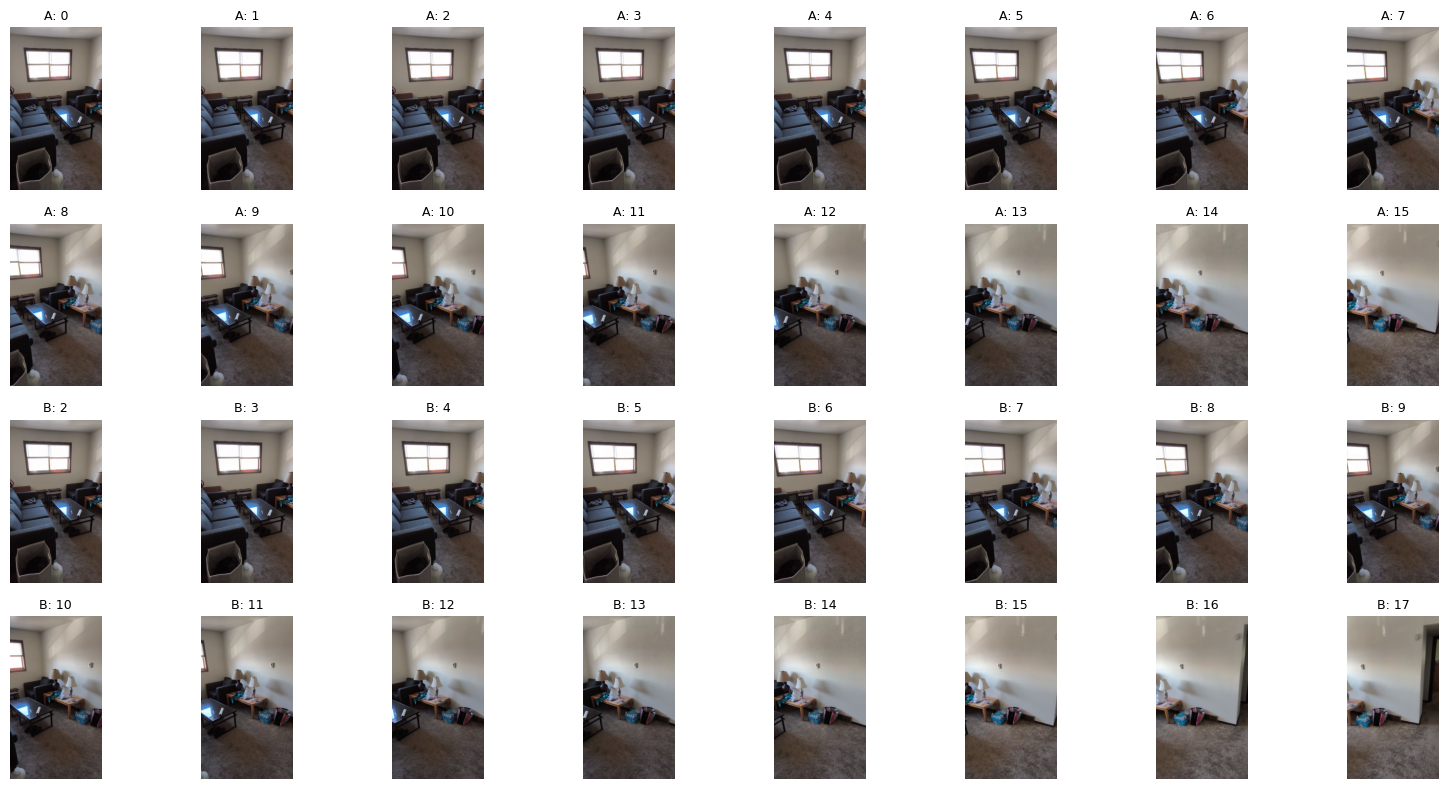

In [47]:
# Show first 16 frames from each sequence
fig, axes = plt.subplots(4, 8, figsize=(16, 8))
for idx in range(16):
    # Video A
    ax = axes[idx // 8, idx % 8]
    frame = video_A[idx].permute(1, 2, 0).detach().cpu().numpy()
    if frame.max() > 1.1:
        frame = frame / 255.0
    ax.imshow(frame)
    ax.axis('off')
    ax.set_title(f"A: {idx}", fontsize=9)
    
    # Video B
    ax = axes[2 + idx // 8, idx % 8]
    frame = video_B[idx].permute(1, 2, 0).detach().cpu().numpy()
    if frame.max() > 1.1:
        frame = frame / 255.0
    ax.imshow(frame)
    ax.axis('off')
    ax.set_title(f"B: {idx+2}", fontsize=9)

plt.tight_layout()
plt.show()

## Process Both Videos Through V-JEPA2

In [48]:
# Process video A (frames 0-63)
processed_A = processor(video_A, return_tensors="pt").to(DEVICE)
with torch.no_grad():
    embeddings_A = model.get_vision_features(**processed_A)

# Process video B (frames 2-65)
processed_B = processor(video_B, return_tensors="pt").to(DEVICE)
with torch.no_grad():
    embeddings_B = model.get_vision_features(**processed_B)

print(f"Embeddings A shape: {embeddings_A.shape}")  # [1, 8192, 1024]
print(f"Embeddings B shape: {embeddings_B.shape}")  # [1, 8192, 1024]

Embeddings A shape: torch.Size([1, 8192, 1024])
Embeddings B shape: torch.Size([1, 8192, 1024])


## Reshape Embeddings to Per-Frame Representations

In [49]:
num_frames = 64
patches_per_frame = embeddings_A.shape[1] // num_frames
feature_dim = embeddings_A.shape[2]

# Reshape to (frames, patches_per_frame, feature_dim) - keep all patches!
emb_A = embeddings_A[0].cpu().numpy().reshape(num_frames, patches_per_frame, feature_dim)
emb_B = embeddings_B[0].cpu().numpy().reshape(num_frames, patches_per_frame, feature_dim)

print(f"Embeddings A shape: {emb_A.shape}")  # (64, 128, 1024)
print(f"Embeddings B shape: {emb_B.shape}")  # (64, 128, 1024)
print(f"Patches per frame: {patches_per_frame}")

Embeddings A shape: (64, 128, 1024)
Embeddings B shape: (64, 128, 1024)
Patches per frame: 128


## Compare Overlapping Frames

Frames 2-63 from Video A correspond to frames 0-61 in Video B.
We'll compare these 62 overlapping frames.

In [50]:
# Extract overlapping frames (keeping all patches)
# Video A: frames 2-63 (indices 2-63)
# Video B: frames 2-63 (indices 0-61 in B, since B starts at frame 2)
overlap_A = emb_A[2:64]  # shape (62, 128, 1024) - actual frames 2-63
overlap_B = emb_B[0:62]  # shape (62, 128, 1024) - also actual frames 2-63

print(f"Overlapping embeddings from A: {overlap_A.shape}")
print(f"Overlapping embeddings from B: {overlap_B.shape}")
print(f"These represent the SAME frames (2-63) in different temporal contexts")
print(f"Each frame has {patches_per_frame} patches with {feature_dim}-dim features")

Overlapping embeddings from A: (62, 128, 1024)
Overlapping embeddings from B: (62, 128, 1024)
These represent the SAME frames (2-63) in different temporal contexts
Each frame has 128 patches with 1024-dim features


## Compute Distance Metrics

In [51]:
# Compute patch-level L2 distances: (62, 128)
patch_l2_distances = np.linalg.norm(overlap_A - overlap_B, axis=2)

# Per-frame statistics (aggregating over patches)
l2_distances_mean = patch_l2_distances.mean(axis=1)  # Mean L2 over patches per frame
l2_distances_max = patch_l2_distances.max(axis=1)    # Max L2 over patches per frame
l2_distances_min = patch_l2_distances.min(axis=1)    # Min L2 over patches per frame

# Cosine similarity per patch
def cosine_similarity_patches(a, b):
    """Compute cosine similarity for each patch. a, b: (frames, patches, features)"""
    a_norm = a / (np.linalg.norm(a, axis=-1, keepdims=True) + 1e-8)
    b_norm = b / (np.linalg.norm(b, axis=-1, keepdims=True) + 1e-8)
    return (a_norm * b_norm).sum(axis=-1)  # (frames, patches)

patch_cosine_sims = cosine_similarity_patches(overlap_A, overlap_B)  # (62, 128)
cosine_sims_mean = patch_cosine_sims.mean(axis=1)  # Mean cosine sim per frame
cosine_sims_min = patch_cosine_sims.min(axis=1)    # Min cosine sim per frame (worst patch)

print(f"Patch-level L2 distances shape: {patch_l2_distances.shape}")
print(f"\nPer-frame L2 distance (mean over patches):")
print(f"  Mean: {l2_distances_mean.mean():.4f}, Std: {l2_distances_mean.std():.4f}")
print(f"\nPer-frame L2 distance (max over patches - worst patch):")
print(f"  Mean: {l2_distances_max.mean():.4f}, Std: {l2_distances_max.std():.4f}")
print(f"\nPer-frame Cosine similarity (mean over patches):")
print(f"  Mean: {cosine_sims_mean.mean():.4f}, Std: {cosine_sims_mean.std():.4f}")
print(f"\nPer-frame Cosine similarity (min over patches - worst patch):")
print(f"  Mean: {cosine_sims_min.mean():.4f}, Std: {cosine_sims_min.std():.4f}")

Patch-level L2 distances shape: (62, 128)

Per-frame L2 distance (mean over patches):
  Mean: 32.7848, Std: 13.1512

Per-frame L2 distance (max over patches - worst patch):
  Mean: 109.0796, Std: 17.8594

Per-frame Cosine similarity (mean over patches):
  Mean: 0.9164, Std: 0.0585

Per-frame Cosine similarity (min over patches - worst patch):
  Mean: 0.4233, Std: 0.1720


## Visualize Distance Metrics

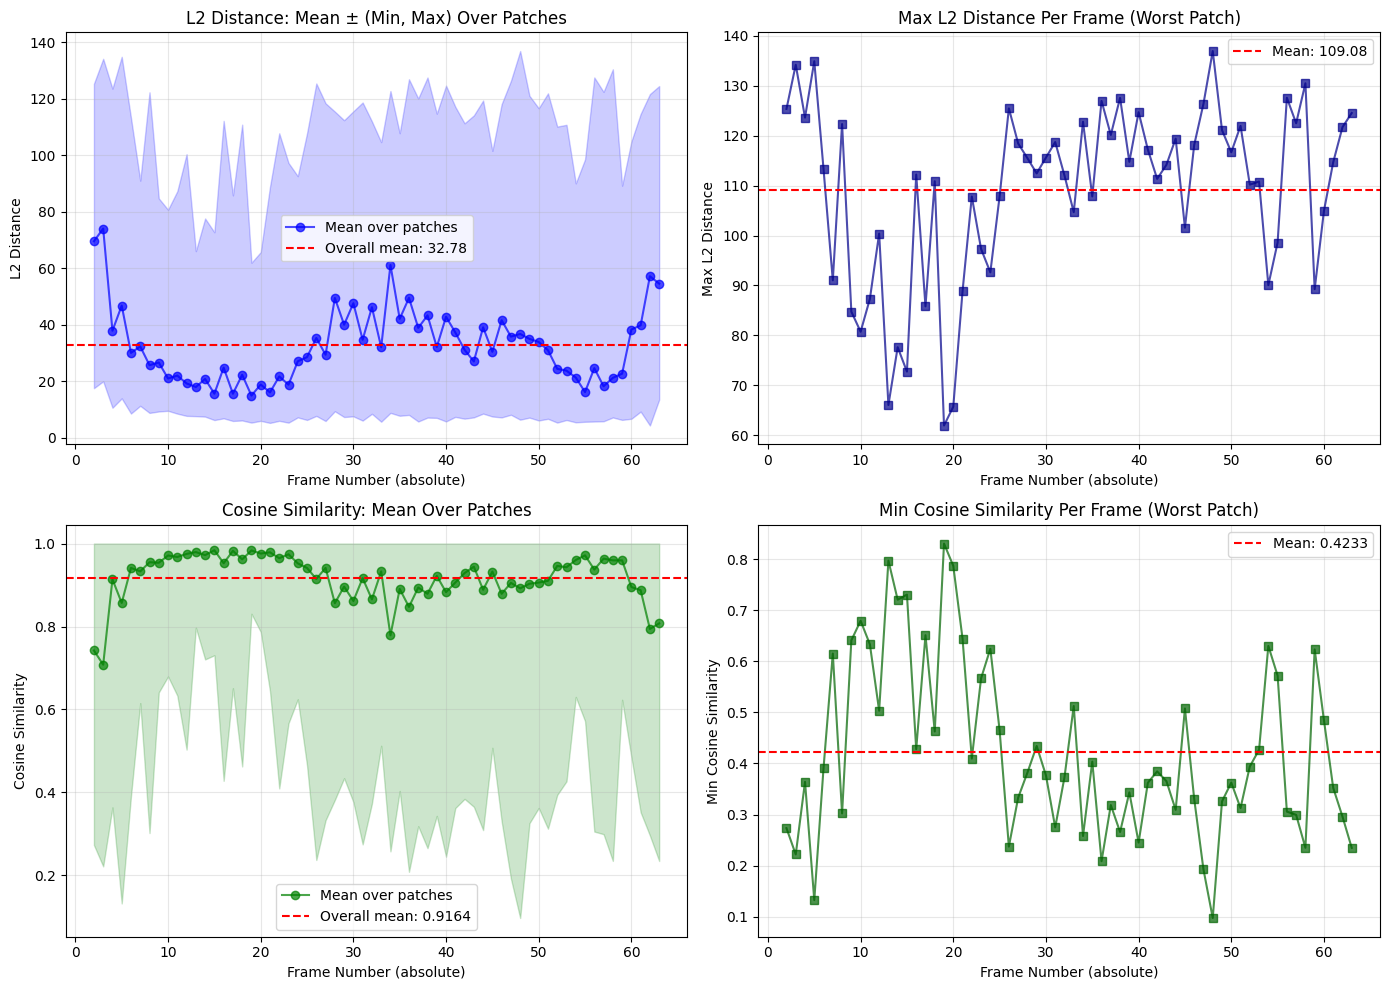

In [52]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

frame_numbers = np.arange(2, 64)

# L2 distance (mean and max over patches)
axes[0, 0].plot(frame_numbers, l2_distances_mean, marker='o', color='blue', alpha=0.7, label='Mean over patches')
axes[0, 0].fill_between(frame_numbers, l2_distances_min, l2_distances_max, alpha=0.2, color='blue')
axes[0, 0].axhline(l2_distances_mean.mean(), color='red', linestyle='--', label=f'Overall mean: {l2_distances_mean.mean():.2f}')
axes[0, 0].set_xlabel('Frame Number (absolute)')
axes[0, 0].set_ylabel('L2 Distance')
axes[0, 0].set_title('L2 Distance: Mean ± (Min, Max) Over Patches')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Max L2 distance per frame (worst patch)
axes[0, 1].plot(frame_numbers, l2_distances_max, marker='s', color='darkblue', alpha=0.7)
axes[0, 1].axhline(l2_distances_max.mean(), color='red', linestyle='--', label=f'Mean: {l2_distances_max.mean():.2f}')
axes[0, 1].set_xlabel('Frame Number (absolute)')
axes[0, 1].set_ylabel('Max L2 Distance')
axes[0, 1].set_title('Max L2 Distance Per Frame (Worst Patch)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Cosine similarity (mean over patches)
axes[1, 0].plot(frame_numbers, cosine_sims_mean, marker='o', color='green', alpha=0.7, label='Mean over patches')
axes[1, 0].fill_between(frame_numbers, cosine_sims_min, np.ones_like(cosine_sims_min), alpha=0.2, color='green')
axes[1, 0].axhline(cosine_sims_mean.mean(), color='red', linestyle='--', label=f'Overall mean: {cosine_sims_mean.mean():.4f}')
axes[1, 0].set_xlabel('Frame Number (absolute)')
axes[1, 0].set_ylabel('Cosine Similarity')
axes[1, 0].set_title('Cosine Similarity: Mean Over Patches')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Min cosine similarity per frame (worst patch)
axes[1, 1].plot(frame_numbers, cosine_sims_min, marker='s', color='darkgreen', alpha=0.7)
axes[1, 1].axhline(cosine_sims_min.mean(), color='red', linestyle='--', label=f'Mean: {cosine_sims_min.mean():.4f}')
axes[1, 1].set_xlabel('Frame Number (absolute)')
axes[1, 1].set_ylabel('Min Cosine Similarity')
axes[1, 1].set_title('Min Cosine Similarity Per Frame (Worst Patch)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Analyze Patch-Level Differences

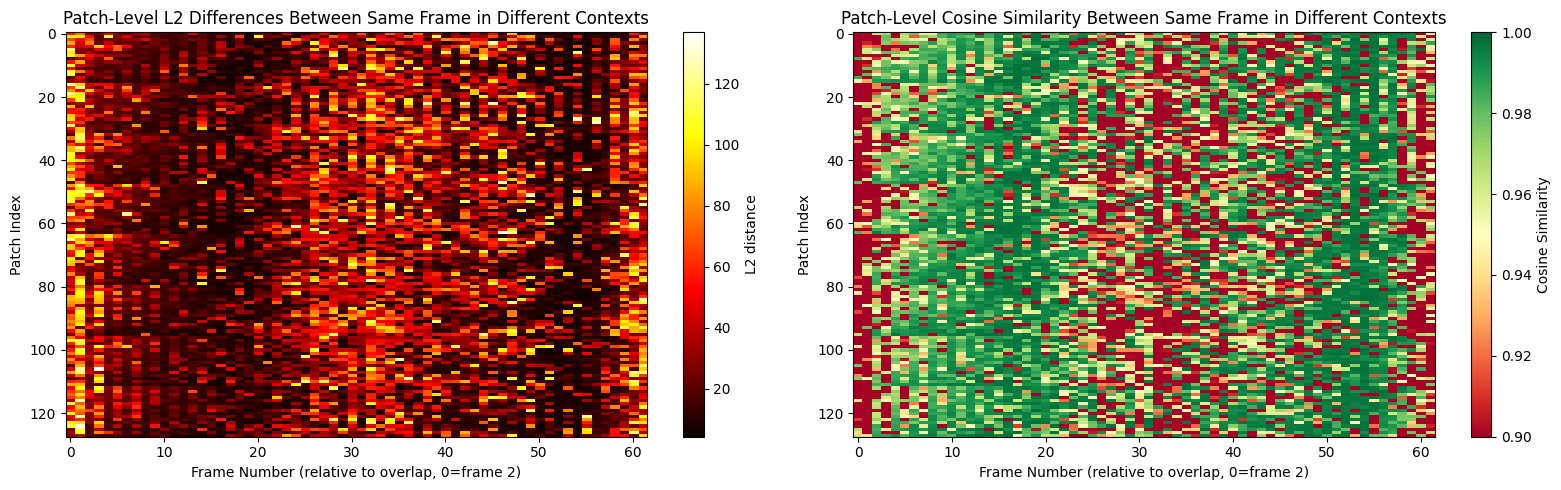

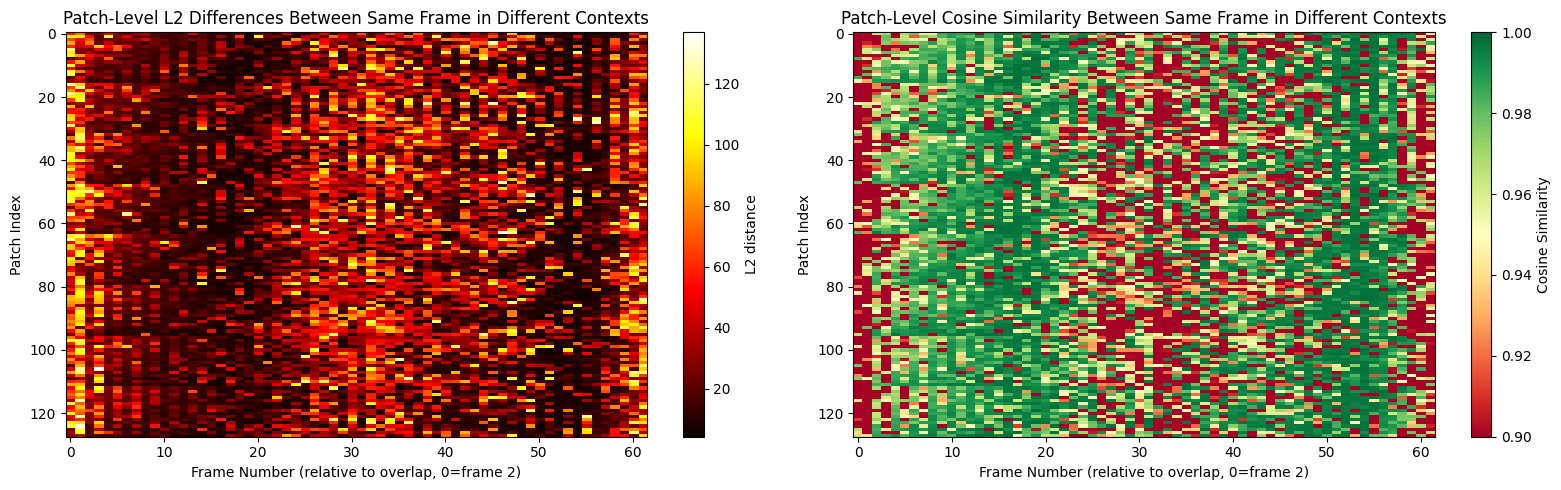

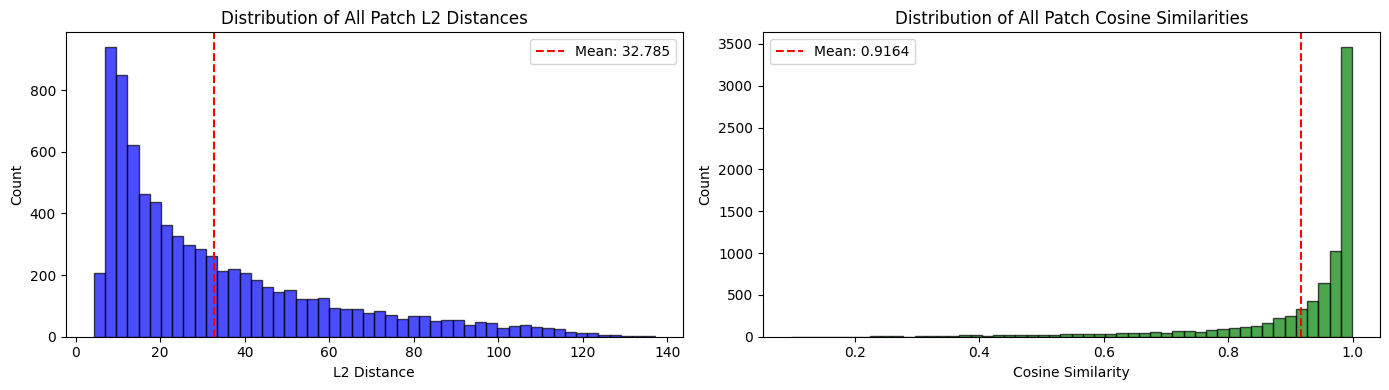

In [53]:
# Visualize patch-level differences as heatmaps
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# L2 distance heatmap
im1 = axes[0].imshow(patch_l2_distances.T, aspect='auto', interpolation='nearest', cmap='hot')
plt.colorbar(im1, ax=axes[0], label='L2 distance')
axes[0].set_xlabel('Frame Number (relative to overlap, 0=frame 2)')
axes[0].set_ylabel('Patch Index')
axes[0].set_title('Patch-Level L2 Differences Between Same Frame in Different Contexts')

# Cosine similarity heatmap
im2 = axes[1].imshow(patch_cosine_sims.T, aspect='auto', interpolation='nearest', cmap='RdYlGn', vmin=0.9, vmax=1.0)
plt.colorbar(im2, ax=axes[1], label='Cosine Similarity')
axes[1].set_xlabel('Frame Number (relative to overlap, 0=frame 2)')
axes[1].set_ylabel('Patch Index')
axes[1].set_title('Patch-Level Cosine Similarity Between Same Frame in Different Contexts')

plt.tight_layout()
plt.show()

# Distribution of patch differences
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(patch_l2_distances.flatten(), bins=50, color='blue', alpha=0.7, edgecolor='black')
axes[0].axvline(patch_l2_distances.mean(), color='red', linestyle='--', label=f'Mean: {patch_l2_distances.mean():.3f}')
axes[0].set_xlabel('L2 Distance')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of All Patch L2 Distances')
axes[0].legend()

axes[1].hist(patch_cosine_sims.flatten(), bins=50, color='green', alpha=0.7, edgecolor='black')
axes[1].axvline(patch_cosine_sims.mean(), color='red', linestyle='--', label=f'Mean: {patch_cosine_sims.mean():.4f}')
axes[1].set_xlabel('Cosine Similarity')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of All Patch Cosine Similarities')
axes[1].legend()

plt.tight_layout()
plt.show()

## Visualization: Joint t-SNE of Both Sequences

Running t-SNE on 1984 patches...


Running t-SNE on 1984 patches...


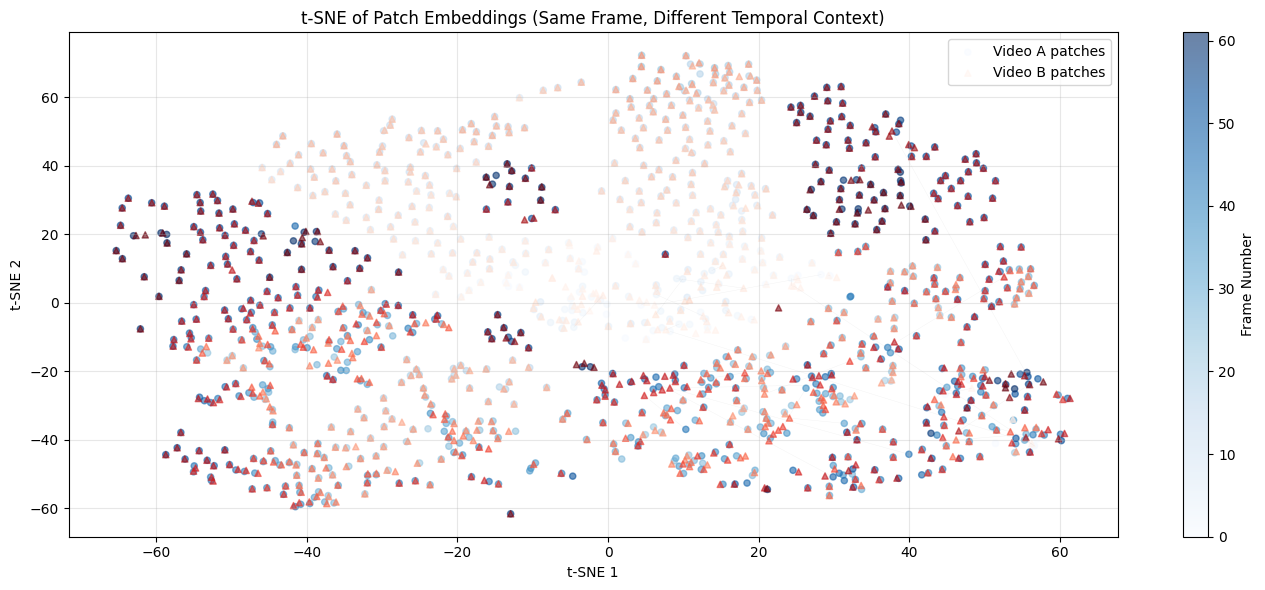

In [54]:
# t-SNE on all patches from overlapping frames
# Flatten: (62 frames, 128 patches, 1024 features) -> (62*128, 1024)
flat_overlap_A = overlap_A.reshape(-1, feature_dim)  # (7936, 1024)
flat_overlap_B = overlap_B.reshape(-1, feature_dim)  # (7936, 1024)

# Subsample for t-SNE efficiency (every 8th patch)
subsample_idx = np.arange(0, flat_overlap_A.shape[0], 8)
sub_A = flat_overlap_A[subsample_idx]
sub_B = flat_overlap_B[subsample_idx]

all_patches = np.vstack([sub_A, sub_B])
print(f"Running t-SNE on {all_patches.shape[0]} patches...")

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
tsne_result = tsne.fit_transform(all_patches)

n_sub = len(subsample_idx)
tsne_A = tsne_result[:n_sub]
tsne_B = tsne_result[n_sub:]

# Color by frame number
frame_ids = np.repeat(np.arange(62), patches_per_frame)[subsample_idx]

plt.figure(figsize=(14, 6))
sc1 = plt.scatter(tsne_A[:, 0], tsne_A[:, 1], c=frame_ids, cmap='Blues', s=20, alpha=0.6, label='Video A patches')
sc2 = plt.scatter(tsne_B[:, 0], tsne_B[:, 1], c=frame_ids, cmap='Reds', s=20, alpha=0.6, label='Video B patches', marker='^')

# Connect corresponding patches with lines (subsample for clarity)
for i in range(0, n_sub, 4):
    plt.plot([tsne_A[i, 0], tsne_B[i, 0]], 
             [tsne_A[i, 1], tsne_B[i, 1]], 
             'gray', alpha=0.1, linewidth=0.3)

plt.colorbar(sc1, label='Frame Number')
plt.legend()
plt.title('t-SNE of Patch Embeddings (Same Frame, Different Temporal Context)')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## PCA Analysis: Alignment Between Sequences

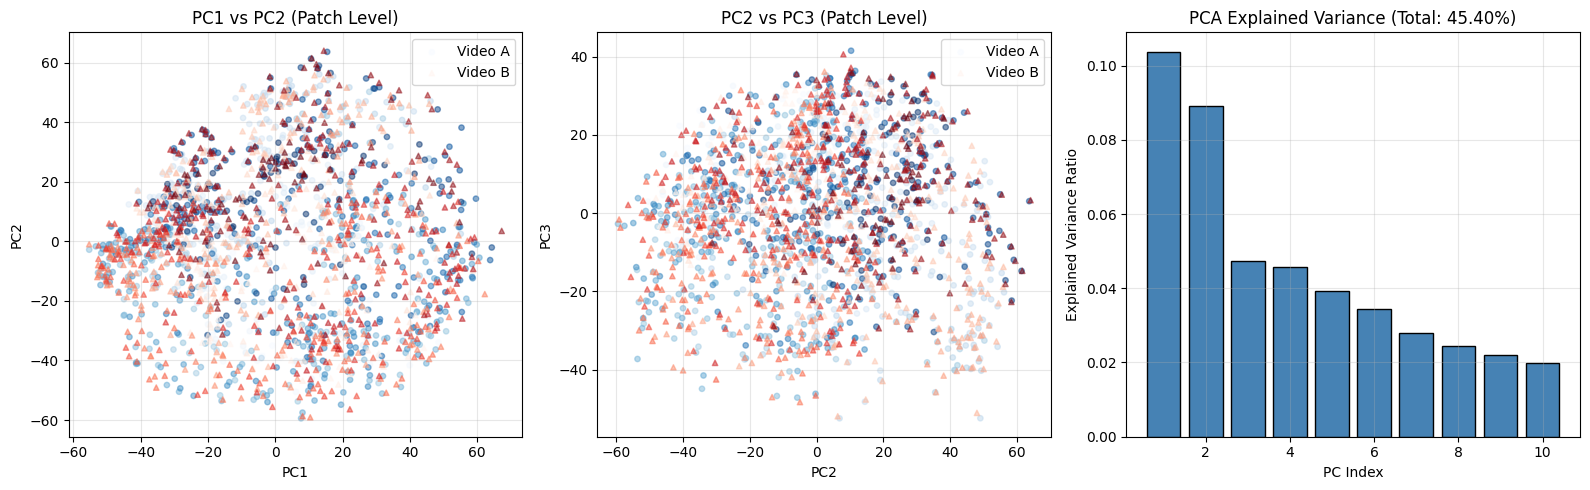

In [55]:
# PCA on all patches
pca = PCA(n_components=10)
pca_result = pca.fit_transform(all_patches)

pca_A = pca_result[:n_sub]
pca_B = pca_result[n_sub:]

fig = plt.figure(figsize=(16, 5))

# PC1 vs PC2
ax1 = fig.add_subplot(1, 3, 1)
ax1.scatter(pca_A[:, 0], pca_A[:, 1], c=frame_ids, cmap='Blues', s=15, alpha=0.5, label='Video A')
ax1.scatter(pca_B[:, 0], pca_B[:, 1], c=frame_ids, cmap='Reds', s=15, alpha=0.5, label='Video B', marker='^')
ax1.set_xlabel('PC1')
ax1.set_ylabel('PC2')
ax1.set_title('PC1 vs PC2 (Patch Level)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# PC2 vs PC3
ax2 = fig.add_subplot(1, 3, 2)
ax2.scatter(pca_A[:, 1], pca_A[:, 2], c=frame_ids, cmap='Blues', s=15, alpha=0.5, label='Video A')
ax2.scatter(pca_B[:, 1], pca_B[:, 2], c=frame_ids, cmap='Reds', s=15, alpha=0.5, label='Video B', marker='^')
ax2.set_xlabel('PC2')
ax2.set_ylabel('PC3')
ax2.set_title('PC2 vs PC3 (Patch Level)')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Explained variance
ax3 = fig.add_subplot(1, 3, 3)
ax3.bar(np.arange(1, 11), pca.explained_variance_ratio_, color='steelblue', edgecolor='black')
ax3.set_xlabel('PC Index')
ax3.set_ylabel('Explained Variance Ratio')
ax3.set_title(f'PCA Explained Variance (Total: {pca.explained_variance_ratio_.sum():.2%})')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Position Effect Analysis

Analyze whether frames at the beginning/end of sequences show larger differences.

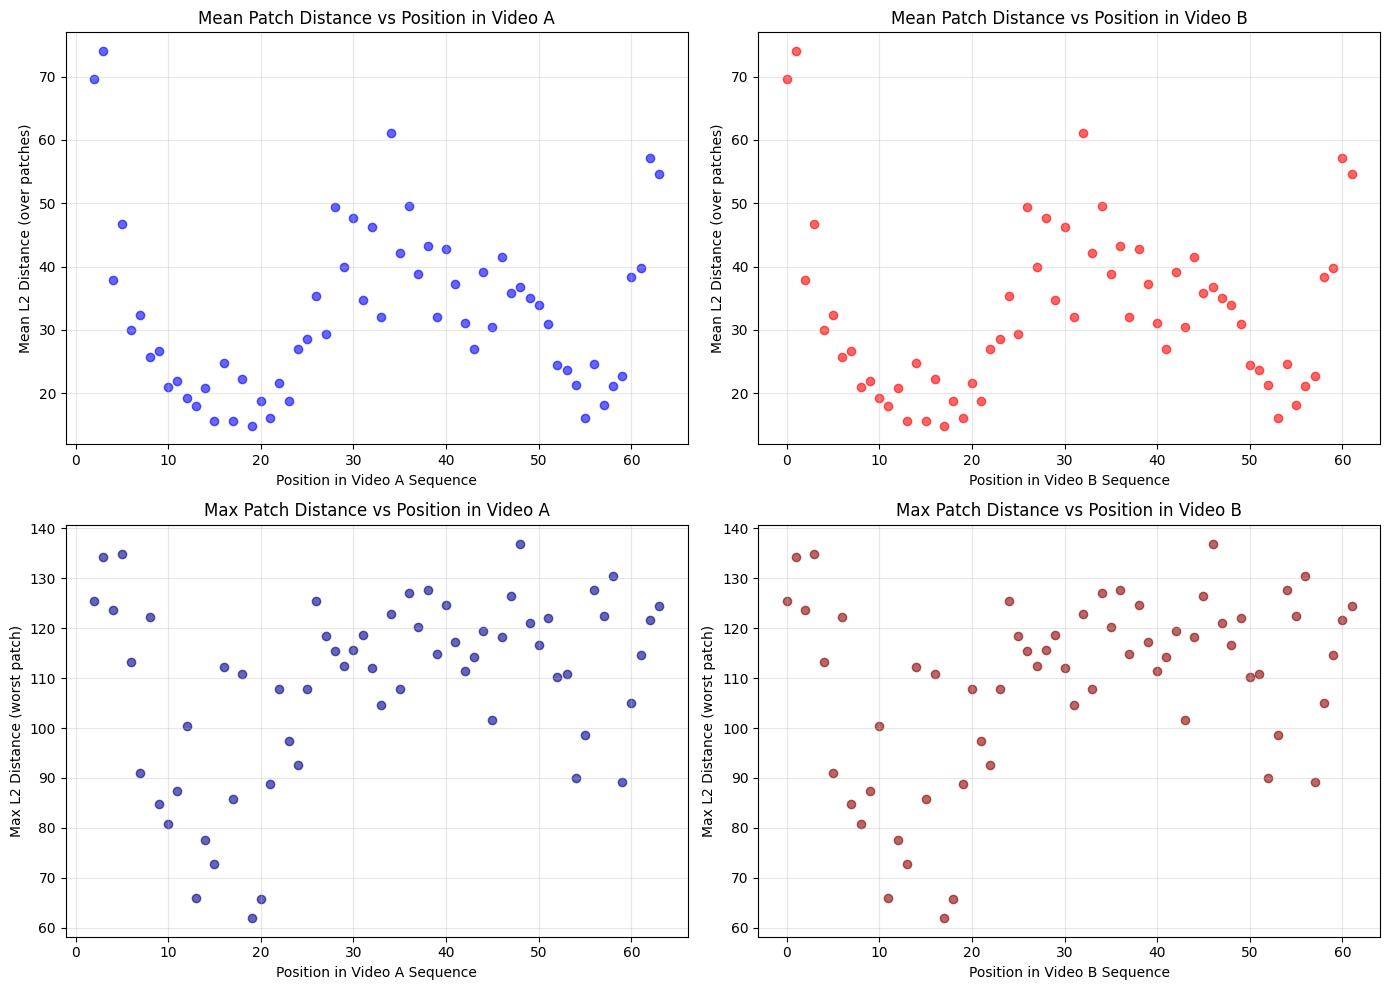

Correlation (mean L2) with position in Video A: r=0.0447, p=0.7300
Correlation (mean L2) with position in Video B: r=0.0447, p=0.7300
Correlation (max L2) with position in Video A: r=0.3191, p=0.0115
Correlation (max L2) with position in Video B: r=0.3191, p=0.0115


In [56]:
# Analyze if distance correlates with position in sequence
positions_A = np.arange(2, 64)  # absolute position in Video A
positions_B = np.arange(0, 62)  # position in Video B sequence

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Mean L2 distance vs position
axes[0, 0].scatter(positions_A, l2_distances_mean, alpha=0.6, color='blue')
axes[0, 0].set_xlabel('Position in Video A Sequence')
axes[0, 0].set_ylabel('Mean L2 Distance (over patches)')
axes[0, 0].set_title('Mean Patch Distance vs Position in Video A')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].scatter(positions_B, l2_distances_mean, alpha=0.6, color='red')
axes[0, 1].set_xlabel('Position in Video B Sequence')
axes[0, 1].set_ylabel('Mean L2 Distance (over patches)')
axes[0, 1].set_title('Mean Patch Distance vs Position in Video B')
axes[0, 1].grid(True, alpha=0.3)

# Max L2 distance vs position
axes[1, 0].scatter(positions_A, l2_distances_max, alpha=0.6, color='darkblue')
axes[1, 0].set_xlabel('Position in Video A Sequence')
axes[1, 0].set_ylabel('Max L2 Distance (worst patch)')
axes[1, 0].set_title('Max Patch Distance vs Position in Video A')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].scatter(positions_B, l2_distances_max, alpha=0.6, color='darkred')
axes[1, 1].set_xlabel('Position in Video B Sequence')
axes[1, 1].set_ylabel('Max L2 Distance (worst patch)')
axes[1, 1].set_title('Max Patch Distance vs Position in Video B')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Correlation analysis
from scipy.stats import pearsonr
corr_mean_A, p_mean_A = pearsonr(positions_A, l2_distances_mean)
corr_mean_B, p_mean_B = pearsonr(positions_B, l2_distances_mean)
corr_max_A, p_max_A = pearsonr(positions_A, l2_distances_max)
corr_max_B, p_max_B = pearsonr(positions_B, l2_distances_max)

print(f"Correlation (mean L2) with position in Video A: r={corr_mean_A:.4f}, p={p_mean_A:.4f}")
print(f"Correlation (mean L2) with position in Video B: r={corr_mean_B:.4f}, p={p_mean_B:.4f}")
print(f"Correlation (max L2) with position in Video A: r={corr_max_A:.4f}, p={p_max_A:.4f}")
print(f"Correlation (max L2) with position in Video B: r={corr_max_B:.4f}, p={p_max_B:.4f}")

## Summary Statistics

In [57]:
print("="*70)
print("TEMPORAL CONTEXT EFFECT SUMMARY (PATCH-LEVEL ANALYSIS)")
print("="*70)
print(f"\nComparing 62 overlapping frames (2-63) between two sequences:")
print(f"  Video A: frames 0-63")
print(f"  Video B: frames 2-65")
print(f"  Each frame has {patches_per_frame} patches with {feature_dim}-dim features")
print(f"  Total patches compared: {62 * patches_per_frame}")

print(f"\n{'='*70}")
print("PATCH-LEVEL DISTANCE METRICS")
print(f"{'='*70}")

print(f"\n  All patches L2 Distance:")
print(f"    Mean: {patch_l2_distances.mean():.4f}")
print(f"    Std:  {patch_l2_distances.std():.4f}")
print(f"    Min:  {patch_l2_distances.min():.4f}")
print(f"    Max:  {patch_l2_distances.max():.4f}")

print(f"\n  All patches Cosine Similarity:")
print(f"    Mean: {patch_cosine_sims.mean():.6f}")
print(f"    Std:  {patch_cosine_sims.std():.6f}")
print(f"    Min:  {patch_cosine_sims.min():.6f}")
print(f"    Max:  {patch_cosine_sims.max():.6f}")

print(f"\n{'='*70}")
print("PER-FRAME STATISTICS (aggregated over patches)")
print(f"{'='*70}")

print(f"\n  Mean L2 per frame:")
print(f"    Mean: {l2_distances_mean.mean():.4f}, Std: {l2_distances_mean.std():.4f}")
print(f"\n  Max L2 per frame (worst patch):")
print(f"    Mean: {l2_distances_max.mean():.4f}, Std: {l2_distances_max.std():.4f}")
print(f"\n  Mean cosine sim per frame:")
print(f"    Mean: {cosine_sims_mean.mean():.6f}, Std: {cosine_sims_mean.std():.6f}")
print(f"\n  Min cosine sim per frame (worst patch):")
print(f"    Mean: {cosine_sims_min.mean():.6f}, Std: {cosine_sims_min.std():.6f}")

print(f"\n{'='*70}")
print("INTERPRETATION")
print(f"{'='*70}")
worst_patch_sim = patch_cosine_sims.min()
mean_patch_sim = patch_cosine_sims.mean()

print(f"\n  Average patch similarity: {mean_patch_sim:.4f}")
print(f"  Worst patch similarity:  {worst_patch_sim:.4f}")

if mean_patch_sim > 0.99:
    print("\n  → Very high avg similarity: Temporal context has minimal effect on most patches")
elif mean_patch_sim > 0.95:
    print("\n  → High avg similarity: Small but measurable temporal context effect")
elif mean_patch_sim > 0.90:
    print("\n  → Moderate avg similarity: Notable temporal context effect")
else:
    print("\n  → Lower avg similarity: Strong temporal context effect")

if worst_patch_sim < 0.90:
    print(f"  → Some patches show significant differences (min sim: {worst_patch_sim:.4f})")
    
print("="*70)

TEMPORAL CONTEXT EFFECT SUMMARY (PATCH-LEVEL ANALYSIS)

Comparing 62 overlapping frames (2-63) between two sequences:
  Video A: frames 0-63
  Video B: frames 2-65
  Each frame has 128 patches with 1024-dim features
  Total patches compared: 7936

PATCH-LEVEL DISTANCE METRICS

  All patches L2 Distance:
    Mean: 32.7848
    Std:  26.3521
    Min:  4.2975
    Max:  136.9364

  All patches Cosine Similarity:
    Mean: 0.916443
    Std:  0.130459
    Min:  0.097288
    Max:  0.998700

PER-FRAME STATISTICS (aggregated over patches)

  Mean L2 per frame:
    Mean: 32.7848, Std: 13.1512

  Max L2 per frame (worst patch):
    Mean: 109.0796, Std: 17.8594

  Mean cosine sim per frame:
    Mean: 0.916443, Std: 0.058548

  Min cosine sim per frame (worst patch):
    Mean: 0.423300, Std: 0.172028

INTERPRETATION

  Average patch similarity: 0.9164
  Worst patch similarity:  0.0973

  → Moderate avg similarity: Notable temporal context effect
  → Some patches show significant differences (min sim